# Cross-stream overview — DE-Har 2025 (May–October)

Multi-panel figure linking meteorology, soil, tree water status, proximal sensing, and LEAF canopy structure.

**Season window:** 1 May – 31 October 2025 (UTC).

**LEAF:** Hemi-hi **20:00 UTC**; `WeightedPAI` at the heights in `TARGET_HEIGHTS` (default **4, 6, 8, 10, 12, 14, 16 m** — edit that list to match native LEAF layers). Two panels: absolute PAI and **min–max normalized** PAI within the season (0–1 per layer) to compare **timing**.

**AngleCam:** Loaded from `data/processed/proximal_rs/anglecam/*_data_24h_mean.csv` (`timestamp` + `value_mean`).


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)


def _repo_root() -> Path:
    p = Path.cwd().resolve()
    for _ in range(8):
        if (p / "data" / "processed").is_dir():
            return p
        p = p.parent
    return Path.cwd().resolve()


ROOT = _repo_root()
PROC = ROOT / "data" / "processed"
YEAR = 2025

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "grid.linewidth": 0.4,
    "font.size": 10,
    "axes.titlesize": 11,
    "legend.frameon": False,
    "figure.dpi": 120,
})

print("ROOT =", ROOT)


ROOT = /mnt/data/lk1167/projects/dehar-spac


In [2]:
def _read_ts(path: Path, **kwargs) -> pd.DataFrame:
    df = pd.read_csv(path, parse_dates=["datetime"], index_col="datetime", **kwargs)
    if df.index.tz is None:
        df.index = df.index.tz_localize("UTC")
    return df.sort_index()


meteo = _read_ts(PROC / "atmosphere_soil" / "meteo_dehar_30min.csv")
soil = _read_ts(PROC / "atmosphere_soil" / "soil_moisture_dehar_30min.csv")
swp = _read_ts(PROC / "physiology" / "stemwater_potential" / "swp_dehar_15min.csv")
sap = _read_ts(PROC / "physiology" / "sap_flux_density" / "sapflow_dehar_30min.csv")
twd = _read_ts(PROC / "physiology" / "twd" / "twd_dehar_30min.csv")
gnss_d = _read_ts(PROC / "proximal_rs" / "gnss_vod" / "gnss_vod_dehar_daily.csv")

leaf_pq = PROC / "proximal_rs" / "leaf" / "leaf_hemi_hi_2025.parquet"
if not leaf_pq.is_file():
    raise FileNotFoundError(f"Missing {leaf_pq} — run leaf batch processing for 2025.")

leaf = pd.read_parquet(leaf_pq)
leaf["datetime"] = pd.to_datetime(leaf["datetime"], utc=True)

# AngleCam: daily mean leaf angle (one series per camera)
ANGLECAM_DIR = PROC / "proximal_rs" / "anglecam"
angle_cams: dict[str, pd.Series] = {}
if ANGLECAM_DIR.is_dir():
    for fp in sorted(ANGLECAM_DIR.glob("leaf_angle_*_data_24h_mean.csv")):
        adf = pd.read_csv(fp, parse_dates=["timestamp"], index_col="timestamp")
        if adf.index.tz is None:
            adf.index = adf.index.tz_localize("UTC")
        stem = fp.stem
        key = stem.replace("_data_24h_mean", "")
        for prefix in ("leaf_angle_tree2_h10546_", "leaf_angle_"):
            if key.startswith(prefix):
                key = key[len(prefix) :]
                break
        angle_cams[key] = adf["value_mean"].astype(float).sort_index()

print("Loaded meteo", meteo.shape, "soil", soil.shape, "swp", swp.shape)
print("sap", sap.shape, "twd", twd.shape, "gnss daily", gnss_d.shape)
print("leaf rows", len(leaf), "| AngleCam:", list(angle_cams.keys()) or "(none)")


Loaded meteo (17520, 6) soil (17520, 8) swp (19148, 3)
sap (15576, 5) twd (15560, 6) gnss daily (237, 12)
leaf rows 97000 | AngleCam: ['camera65', 'camera66', 'camera67']


In [3]:
def in_year(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df.index.year == YEAR)]


def roll3(s: pd.Series) -> pd.Series:
    return s.rolling(2, center=True, min_periods=1).mean()


T0 = pd.Timestamp(f"{YEAR}-05-01", tz="UTC")
T1 = pd.Timestamp(f"{YEAR}-10-31", tz="UTC")

m = in_year(meteo)
s = in_year(soil)
sw = in_year(swp)
sf = in_year(sap)
tw = in_year(twd)
gd = in_year(gnss_d)

d_vpd = m["vpd_hpa"].resample("1D").mean()
d_tmax = m["tair_c"].resample("1D").max()

d_vwc5 = s["vwc_pct_a_5cm"].resample("1D").mean()
d_vwc10 = s["vwc_pct_a_10cm"].resample("1D").mean()
d_vwc20 = s["vwc_pct_a_20cm"].resample("1D").mean()

swp_col = sw.columns[0]
d_swp_min = sw[swp_col].resample("1D").min()
pre = sw.between_time("04:00", "06:00")
d_swp_pre = pre[swp_col].resample("1D").max()

sap_col = "js_h10545" if "js_h10545" in sf.columns else sf.columns[0]
d_sap_max = sf[sap_col].resample("1D").max()

twd_col = "twd_um_h10545" if "twd_um_h10545" in tw.columns else tw.columns[0]
d_twd_max = tw[twd_col].resample("1D").max()

vpd_s = roll3(d_vpd)
tmax_s = roll3(d_tmax)
vwc5_s = roll3(d_vwc5)
vwc10_s = roll3(d_vwc10)
vwc20_s = roll3(d_vwc20)
swp_min_s = roll3(d_swp_min)
swp_pre_s = roll3(d_swp_pre)
sap_s = roll3(d_sap_max)
twd_s = roll3(d_twd_max)

pre_g = "nvod_predawn_gps3"
aft_g = "nvod_afternoon_gps3"
if pre_g not in gd.columns:
    pre_g, aft_g = "nvod_predawn_gps1", "nvod_afternoon_gps1"
gnss_pre_s = roll3(gd[pre_g])
gnss_aft_s = roll3(gd[aft_g])


def win(s: pd.Series) -> pd.Series:
    return s.loc[T0:T1]


print("Season:", T0.date(), "→", T1.date(), "| daily meteo rows", len(d_vpd), "| GNSS", len(gd))


Season: 2025-05-01 → 2025-10-31 | daily meteo rows 334 | GNSS 237


In [4]:
SCAN_HOUR = 20
PAI_COL = "WeightedPAI"
# Native LEAF layers are on a 0.5 m grid (e.g. 6.5, 8.5 m for AngleCam heights).
TARGET_HEIGHTS = [2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0]

lf = leaf[(leaf["datetime"].dt.year == YEAR) & (leaf["scan_hour"] == SCAN_HOUR)].copy()
lf = lf.drop_duplicates(subset=["datetime", "height"])

pai_by_h = {}
for h in TARGET_HEIGHTS:
    sub = lf[lf["height"] == h].sort_values("datetime")
    s = sub.set_index("datetime")[PAI_COL].sort_index()
    pai_by_h[h] = roll3(s)
    print(f"  {h:.0f} m: {s.notna().sum()} scans")


def minmax_season(s: pd.Series, t0, t1) -> pd.Series:
    w = s.loc[t0:t1].dropna()
    if w.empty:
        return s * np.nan
    lo, hi = float(np.nanpercentile(w,0)), float(np.nanpercentile(w,100))
    if hi <= lo:
        return pd.Series(0.0, index=s.index)
    return (s - lo) / (hi - lo)


pai_norm = {h: minmax_season(pai_by_h[h], T0, T1) for h in TARGET_HEIGHTS}


  2 m: 243 scans
  3 m: 243 scans
  4 m: 243 scans
  5 m: 243 scans
  6 m: 243 scans
  7 m: 243 scans
  8 m: 243 scans
  9 m: 243 scans
  10 m: 243 scans
  11 m: 243 scans
  12 m: 243 scans
  13 m: 243 scans
  14 m: 243 scans
  15 m: 243 scans
  16 m: 243 scans
  17 m: 243 scans
  18 m: 243 scans
  19 m: 243 scans
  20 m: 243 scans


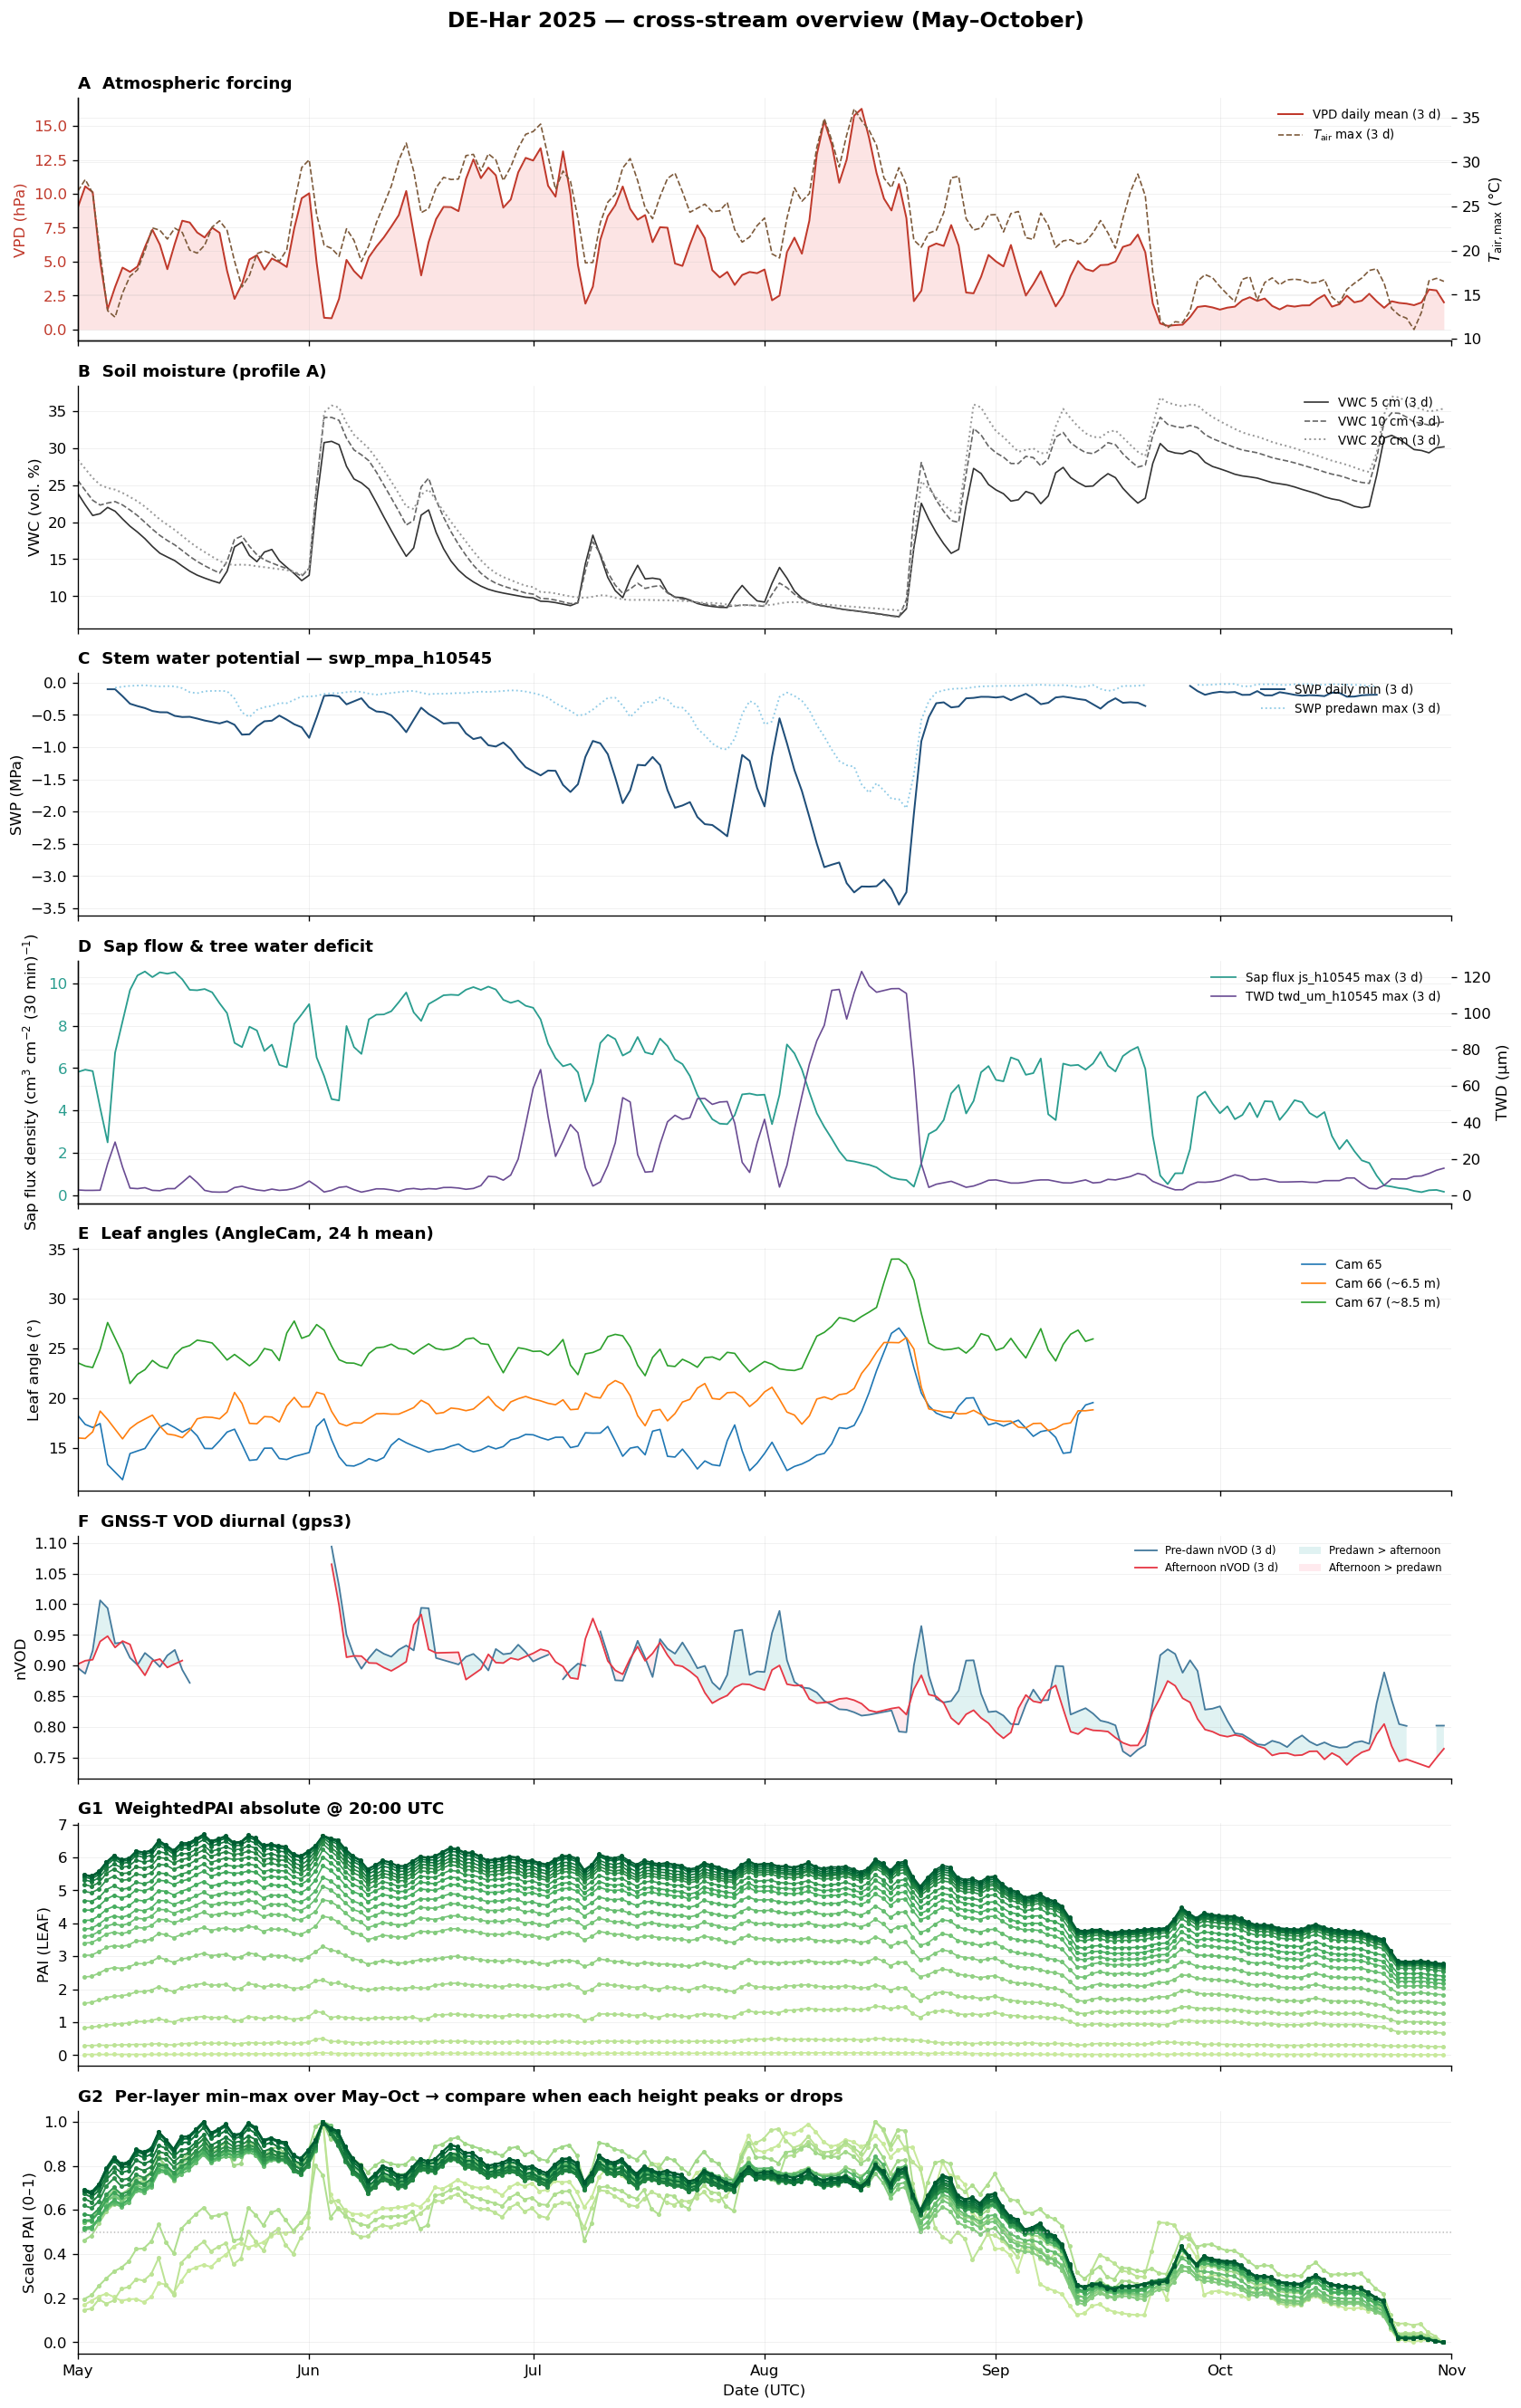

In [5]:
fig, axes = plt.subplots(8, 1, figsize=(14, 22), sharex=True)
fig.suptitle(
    f"DE-Har {YEAR} — cross-stream overview (May–October)",
    fontsize=14,
    fontweight="semibold",
    y=1.005,
)

# --- A: VPD + Tmax ---
ax = axes[0]
vp = win(vpd_s)
tm = win(tmax_s)
ax.fill_between(vp.index, 0, vp, color="#f8b4b4", alpha=0.35, linewidth=0)
ax.plot(vp.index, vp, color="#c0392b", lw=1.2, label="VPD daily mean (3 d)")
ax.set_ylabel("VPD (hPa)", color="#c0392b")
ax.tick_params(axis="y", labelcolor="#c0392b")
ax2 = ax.twinx()
ax2.plot(tm.index, tm, color="#7d5a3b", ls="--", lw=1.0, label=r"$T_\mathrm{air}$ max (3 d)")
ax2.set_ylabel(r"$T_\mathrm{air,max}$ (°C)")
ax.set_title("A  Atmospheric forcing", loc="left", fontweight="semibold")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

# --- B: soil moisture 5 / 10 / 20 cm ---
ax = axes[1]
ax.plot(win(vwc5_s).index, win(vwc5_s), color="#333", lw=1.0, label="VWC 5 cm (3 d)")
ax.plot(win(vwc10_s).index, win(vwc10_s), color="#666", ls="--", lw=1.0, label="VWC 10 cm (3 d)")
ax.plot(win(vwc20_s).index, win(vwc20_s), color="#999", ls=":", lw=1.2, label="VWC 20 cm (3 d)")
ax.set_ylabel("VWC (vol. %)")
ax.set_title("B  Soil moisture (profile A)", loc="left", fontweight="semibold")
ax.legend(loc="upper right", fontsize=8)

# --- C: SWP ---
ax = axes[2]
ax.plot(win(swp_min_s).index, win(swp_min_s), color="#1f4e79", lw=1.2, label="SWP daily min (3 d)")
ax.plot(win(swp_pre_s).index, win(swp_pre_s), color="#8ecae6", ls=":", lw=1.1, label="SWP predawn max (3 d)")
ax.set_ylabel("SWP (MPa)")
ax.set_title(f"C  Stem water potential — {swp_col}", loc="left", fontweight="semibold")
ax.legend(loc="upper right", fontsize=8)

# --- D: Sap + TWD ---
ax = axes[3]
sp = win(sap_s)
tw_ = win(twd_s)
ax.plot(sp.index, sp, color="#2a9d8f", lw=1.1, label=f"Sap flux {sap_col} max (3 d)")
ax.set_ylabel(r"Sap flux density (cm$^3$ cm$^{-2}$ (30 min)$^{-1}$)")
ax.tick_params(axis="y", labelcolor="#2a9d8f")
ax2 = ax.twinx()
ax2.plot(tw_.index, tw_, color="#6a4c93", lw=1.0, label=f"TWD {twd_col} max (3 d)")
ax2.set_ylabel("TWD (µm)")
ax.set_title("D  Sap flow & tree water deficit", loc="left", fontweight="semibold")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper right", fontsize=8)

# --- E: AngleCam ---
ax = axes[4]
CAM_LABELS = {
    "camera65": "Cam 65",
    "camera66": "Cam 66 (~6.5 m)",
    "camera67": "Cam 67 (~8.5 m)",
    "tree2_h10546_camera65": "Cam 65",
    "tree2_h10546_camera66": "Cam 66 (~6.5 m)",
    "tree2_h10546_camera67": "Cam 67 (~8.5 m)",
}
if angle_cams:
    for key, ser in angle_cams.items():
        lbl = CAM_LABELS.get(key, key)
        sm = win(roll3(ser))
        ax.plot(sm.index, sm.values, lw=1.0, label=lbl)
    ax.set_ylabel("Leaf angle (°)")
    ax.legend(loc="upper right", fontsize=8)
else:
    ax.text(
        0.5,
        0.5,
        "No CSVs in proximal_rs/anglecam/",
        transform=ax.transAxes,
        ha="center",
        va="center",
        fontsize=11,
        color="#666",
    )
    ax.set_ylabel("Leaf angle (°)")
ax.set_title("E  Leaf angles (AngleCam, 24 h mean)", loc="left", fontweight="semibold")

# --- F: GNSS-T nVOD ---
ax = axes[5]
gp, ga = win(gnss_pre_s), win(gnss_aft_s)
ax.plot(gp.index, gp, color="#457b9d", lw=1.1, label="Pre-dawn nVOD (3 d)")
ax.plot(ga.index, ga, color="#e63946", lw=1.1, label="Afternoon nVOD (3 d)")
idx = gp.index.intersection(ga.index)
gp2, ga2 = gp.reindex(idx), ga.reindex(idx)
diff = gp2 - ga2
ax.fill_between(
    idx,
    ga2,
    gp2,
    where=(diff >= 0),
    interpolate=True,
    color="#a8dadc",
    alpha=0.35,
    linewidth=0,
    label="Predawn > afternoon",
)
ax.fill_between(
    idx,
    ga2,
    gp2,
    where=(diff < 0),
    interpolate=True,
    color="#ffccd5",
    alpha=0.4,
    linewidth=0,
    label="Afternoon > predawn",
)
ax.set_ylabel("nVOD")
ax.set_title(
    f"F  GNSS-T VOD diurnal ({pre_g.replace('nvod_predawn_', '')})",
    loc="left",
    fontweight="semibold",
)
ax.legend(loc="upper right", fontsize=7, ncol=2)

# --- G1: LEAF PAI absolute ---
ax = axes[6]
_n = len(TARGET_HEIGHTS)
colors = plt.cm.YlGn(np.linspace(0.3, 0.92, _n))
_ms = 2.0 if _n > 5 else 2.5
for h, clr in zip(TARGET_HEIGHTS, colors):
    s = win(pai_by_h[h])
    lbl = f"{int(h)} m" if float(h).is_integer() else f"{h:g} m"
    ax.plot(s.index, s, marker="o", ms=_ms, lw=1.0, color=clr, label=lbl)
ax.set_ylabel("PAI (LEAF)")
ax.set_title(
    f"G1  {PAI_COL} absolute @ {SCAN_HOUR:02d}:00 UTC",
    loc="left",
    fontweight="semibold",
)
#ax.legend(loc="upper right", fontsize=8, title="Height")

# --- G2: same layers min–max scaled within May–Oct (timing / lead–lag) ---
ax = axes[7]
for h, clr in zip(TARGET_HEIGHTS, colors):
    s = win(pai_norm[h])
    lbl = f"{int(h)} m" if float(h).is_integer() else f"{h:g} m"
    ax.plot(s.index, s, marker="o", ms=_ms, lw=1.2, color=clr, label=lbl)
ax.axhline(0.5, color="#bbbbbb", ls=":", lw=0.9)
ax.set_ylabel("Scaled PAI (0–1)")
ax.set_ylim(-0.05, 1.05)
ax.set_title(
    "G2  Per-layer min–max over May–Oct → compare when each height peaks or drops",
    loc="left",
    fontweight="semibold",
)
#ax.legend(loc="upper right", fontsize=8, title="Height")

axes[-1].set_xlabel("Date (UTC)")
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
plt.xlim(T0, T1 + pd.Timedelta(days=1))
plt.tight_layout()
plt.show()


### Processed files used

| Panel | File |
|-------|------|
| A | `atmosphere_soil/meteo_dehar_30min.csv` |
| B | `atmosphere_soil/soil_moisture_dehar_30min.csv` (5 / 10 / 20 cm, profile A) |
| C | `physiology/stemwater_potential/swp_dehar_15min.csv` |
| D | `physiology/sap_flux_density/sapflow_dehar_30min.csv`, `physiology/twd/twd_dehar_30min.csv` |
| E | `proximal_rs/anglecam/leaf_angle_*_data_24h_mean.csv` |
| F | `proximal_rs/gnss_vod/gnss_vod_dehar_daily.csv` |
| G | `proximal_rs/leaf/leaf_hemi_hi_2025.parquet` |
